# 01 — Data Exploration: Findings

## Dataset shapes
- Vinted: 7,723 rows × 15 columns
- Kleinanzeigen: 4,000 rows × 16 columns (extra: `price_type`)

## Schema diff
- Identical schemas except KA-only `price_type` column.
- Condition strings inconsistent across platforms: "Sehr gut" vs "Sehr Gut", "Neu, mit Etikett" vs "Neu mit Etikett".
- Resolution: normalize via `.str.lower().str.replace(",", "").str.strip()` — collapses cleanly to 6 buckets.

## Category taxonomy (no overlap)
- Vinted: 4 item-type categories (jackets, jeans, tshirts, sneakers).
- KA: 4 gender × clothing/shoes categories (Damen/Herrenbekleidung, Damen/Herrenschuhe).
- **Decision: keep both vocabularies native.** No mapping table built. Model #1 will be trained on combined data; at inference it will be called twice (one prompt per platform) so it produces platform-native categories and platform-tone descriptions in a single architecture.

## Condition normalization
- 6 unified buckets after normalization.
- Drop `in ordnung` (56 rows) and `zufriedenstellend` (54 rows) — too few for training.
- Train on remaining 5 buckets (~11,500 rows combined).

## Pre-training filters required
- Drop rows with `description.str.len() < 30`.
- Drop rows with null `price` or null `category_name`.
- Drop KA rows where `price_type == 'PLEASE_CONTACT'` (placeholder prices).
- Drop the `in ordnung` / `zufriedenstellend` condition rows.

## Language
- Vinted: 38% French, 21% Italian, 21% German, 8% English, 8% Dutch, rest small.
- KA: 98% German.
- Decision for the spike: filter Vinted to `language == 'de'` only — keeps the spike interpretable. Revisit post-spike whether to include other languages.

## Brand
- Vinted: 1.7% null, long-tail distribution. Top brands: Levi's, Nike, adidas, Zara, Tommy Hilfiger.
- KA: 0% null, but ~25% are `Sonstige` (placeholder for "other"). Map both `Sonstige` and OOV brands to a single UNK token in the brand embedding lookup.
- 15 brands appear in both platforms' top 30 — validates the cross-platform comparison pitch.

## Class imbalance — handled per the brief
- Flaw head: ~1:5 positive:negative after filtering. Mitigation: class-weighted BCE with `pos_weight ≈ num_negatives / num_positives`. Threshold tuning on val set, not hardcoded 0.5.
- Price head: heavy right-skew distribution. Mitigation: log-transform target + quantile loss across q={0.1, 0.25, 0.5, 0.75, 0.9}.
- Sell-likelihood head: imbalance unknown until sold-status scrape lands. Will use class-weighted BCE; if extreme, use this signal to lock the time window (7/14/30 days).
- Brand: long tail. Handled via OOV→UNK mapping.
- Category: relatively balanced per platform; stratification of test set on category × condition × platform handles it.

## Image storage
- Both datasets store images as `{'bytes': ..., 'path': ...}` dicts (HuggingFace datasets format). Sanity check: 50/50 load successfully on both platforms.

## Decisions locked for the spike
- Use combined Vinted (de-only) + KA dataset for fine-tuning.
- Native category vocabularies kept separate; VLM will be inferenced twice (per platform) at runtime.
- Drop the 2 smallest condition buckets, keep 5.
- Filter `price_type == 'PLEASE_CONTACT'` before any price-head work.
- Map `Sonstige` brand → UNK.

## Open questions
- Sold-status time window (7/14/30 days) — pending re-scrape data shape.
- Whether to include non-German Vinted languages post-spike — depends on whether the chosen VLM handles cross-lingual generation cleanly.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from io import BytesIO
import warnings
import random

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_columns', 60)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

VINTED_PATH = "../data/vinted_clothing_v1_5_full.parquet"
KA_PATH     = "../data/kleinanzeigen_clothing_v1.parquet"


def load_img(val):
    """Load PIL Image from bytes, HuggingFace dict, or file path. Returns None on failure."""
    if val is None:
        return None
    try:
        if isinstance(val, dict):  # HuggingFace datasets format
            if val.get('bytes'):
                return Image.open(BytesIO(val['bytes'])).convert('RGB')
            if val.get('path'):
                return Image.open(val['path']).convert('RGB')
        if isinstance(val, bytes):
            return Image.open(BytesIO(val)).convert('RGB')
        if isinstance(val, str) and val:
            return Image.open(val).convert('RGB')
    except Exception:
        pass
    return None


def find_col(df, candidates):
    """Return the first candidate column name that exists in df, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None


print('Imports OK')

Imports OK


In [28]:
vt = pd.read_parquet(VINTED_PATH)
ka = pd.read_parquet(KA_PATH)

print(f"Vinted        : {vt.shape[0]:,} rows × {vt.shape[1]} columns")
print(f"Kleinanzeigen : {ka.shape[0]:,} rows × {ka.shape[1]} columns")


def overview_table(df, name):
    t = pd.DataFrame({
        'dtype':   df.dtypes.astype(str),
        'nulls':   df.isnull().sum(),
        'null%':   (df.isnull().mean() * 100).round(1),
        'example': [str(df[c].dropna().iloc[0])[:80] if df[c].notna().any() else '' for c in df.columns],
    })
    t.index.name = 'column'
    print(f"\n{'═'*70}")
    print(f"  {name}")
    print(f"{'═'*70}")
    display(t)

overview_table(vt, 'VINTED')
overview_table(ka, 'KLEINANZEIGEN')

Vinted        : 7,723 rows × 15 columns
Kleinanzeigen : 4,000 rows × 16 columns

══════════════════════════════════════════════════════════════════════
  VINTED
══════════════════════════════════════════════════════════════════════


,dtype,nulls,null%,example
column,,,,
image,object,0,0.0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00
target_text,str,0,0.0,Titel: VOGUE Collection Polo Shirt\nBeschreibung: Creme farbenes Poloshirt von VO
id,int64,0,0.0,8758496421
title,str,0,0.0,VOGUE Collection Polo Shirt
description,str,0,0.0,Creme farbenes Poloshirt von VOGUE Collection. Selten getragen da mir leider zu
category_name,str,0,0.0,tshirts
catalog_id,int64,0,0.0,221
price,float32,0,0.0,19.0
currency,str,0,0.0,EUR



══════════════════════════════════════════════════════════════════════
  KLEINANZEIGEN
══════════════════════════════════════════════════════════════════════


,dtype,nulls,null%,example
column,,,,
image,object,0,0.0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00
target_text,str,0,0.0,Titel: Ärmelloses Jeanskleid hellblau Gr. S\nBeschreibung: Ich biete ein schönes
id,int64,0,0.0,3400326809
title,str,0,0.0,Ärmelloses Jeanskleid hellblau Gr. S
description,str,0,0.0,Ich biete ein schönes ärmelloses Jeanskleid in einem hellen Blauton an. Dieses K
category_name,str,0,0.0,Damenbekleidung
catalog_id,int64,0,0.0,154
price,float32,0,0.0,10.0
price_type,str,0,0.0,SPECIFIED_AMOUNT


In [29]:
vt_cols = set(vt.columns)
ka_cols = set(ka.columns)
shared   = sorted(vt_cols & ka_cols)
vt_only  = sorted(vt_cols - ka_cols)
ka_only  = sorted(ka_cols - vt_cols)

print(f"Shared columns ({len(shared)}):")
for c in shared:
    dt_v = str(vt[c].dtype)
    dt_k = str(ka[c].dtype)
    flag = '  ⚠  DTYPE MISMATCH' if dt_v != dt_k else ''
    print(f"  {c:<35} vinted={dt_v:<12} ka={dt_k}{flag}")

print(f"\nVinted-only  ({len(vt_only)}): {vt_only}")
print(f"KA-only      ({len(ka_only)}): {ka_only}")

Shared columns (15):
  brand                               vinted=str          ka=str
  catalog_id                          vinted=int64        ka=int64
  category_name                       vinted=str          ka=str
  color                               vinted=str          ka=str
  condition                           vinted=str          ka=str
  currency                            vinted=str          ka=str
  description                         vinted=str          ka=str
  id                                  vinted=int64        ka=int64
  image                               vinted=object       ka=object
  language                            vinted=str          ka=str
  price                               vinted=float32      ka=float32
  size                                vinted=str          ka=str
  source_domain                       vinted=str          ka=str
  target_text                         vinted=str          ka=str
  title                               vinted=str          

---
## Vinted

Image column : image
Text columns : ['target_text', 'title', 'description', 'category_name', 'currency', 'brand', 'size', 'color', 'condition', 'language', 'source_domain']


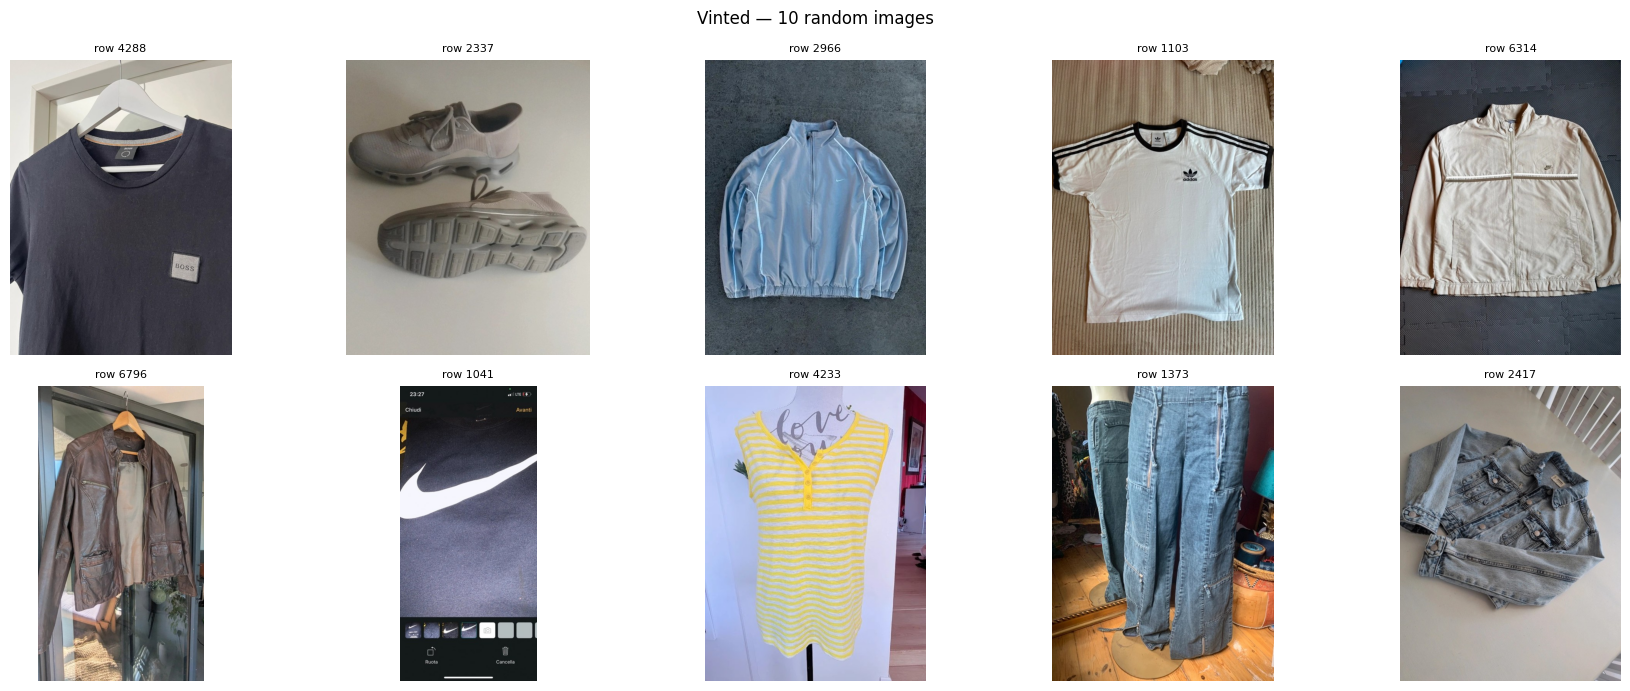


Text fields for the same 10 rows:


,target_text,title,description,category_name,currency,brand,size,color,condition,language,source_domain
0,Titel: T shirt noir homme BOSS taille Xs\nBeschreibung: 🏷️ : colis emballé et soigné. 📦 : envoie sous 48H ( sauf...,T shirt noir homme BOSS taille Xs,🏷️ : colis emballé et soigné. 📦 : envoie sous 48H ( sauf si raison personnelle )\n📏 taille : Xs\n💵 prix : négoci...,tshirts,EUR,Boss,XS,Schwarz,Neu,fr,www.vinted.fr
1,Titel: Neuwertige Skechers slip ins gowalk glide step 2.0 belah taupe grösse 40\nBeschreibung: -PRIVATVERKAUF-\nGrosse 40\nPasst für 40/41\nInnens...,Neuwertige Skechers slip ins gowalk glide step 2.0 belah taupe grösse 40,-PRIVATVERKAUF-\nGrosse 40\nPasst für 40/41\nInnensohle hat 27 cm\nSkechers slip ins go walk glide step 2.0 belah\nBequeme hochwertige leichte sta...,sneakers,EUR,Skechers,40,Beige,Neu,de,www.vinted.fr
2,"Titel: 2003 Nike Lined Trackjacket (Archive, Y2K) Vintage\nBeschreibung: Splendido pezzo d'archivio Nike dei primi anni 2000, un mix perfetto tra ...","2003 Nike Lined Trackjacket (Archive, Y2K) Vintage","Splendido pezzo d'archivio Nike dei primi anni 2000, un mix perfetto tra estetica sportiva retro e tendenze streetwear attuali. Questa giacca a ve...",jackets,EUR,Nike,XL,Grau,Neu,en,www.vinted.fr
3,"Titel: Adidas Originals T-Shirt Weiß Schwarz Vintage S Sommer\nBeschreibung: Hi, ich verkaufe ein Adidas Originals T-Shirt in weiß mit schwarzen D...",Adidas Originals T-Shirt Weiß Schwarz Vintage S Sommer,"Hi, ich verkaufe ein Adidas Originals T-Shirt in weiß mit schwarzen Details und klassischem Trefoil Logo auf der Brust. Das Shirt hat die typische...",tshirts,EUR,adidas,S,Weiß,Sehr gut,de,www.vinted.fr
4,Titel: Vintage Nike Windbreaker / Jacke Beige – Gr. L – 90s/Y2K\nBeschreibung: Verkaufe diese authentische Nike Vintage Windbreaker Jacke in einem...,Vintage Nike Windbreaker / Jacke Beige – Gr. L – 90s/Y2K,Verkaufe diese authentische Nike Vintage Windbreaker Jacke in einem schönen Beige/Taupe (Earth Tones). Perfekter Boxy-Fit für den angesagten Stree...,jackets,EUR,Nike,L,Beige,Gut,de,www.vinted.fr
5,"Titel: Blouson en cuir IKKS\nBeschreibung: Coupe femme, légèrement ceintrée\n10% Cuir d'agneau \nTrès peu porté \nDimensions :\nHauteur 62cm\nÉpau...",Blouson en cuir IKKS,"Coupe femme, légèrement ceintrée\n10% Cuir d'agneau \nTrès peu porté \nDimensions :\nHauteur 62cm\nÉpaule à épaule 45 cm\nManches 66cm\nLargeur (a...",jackets,EUR,IKKS,XL / 42 / 14,Braun,Sehr gut,fr,www.vinted.fr
6,"Titel: Prezzo già basso per vendita veloce, Maglietta Nike taglia M unisex – sportiva leggera traspirante\nBeschreibung: Maglietta Nike a maniche ...","Prezzo già basso per vendita veloce, Maglietta Nike taglia M unisex – sportiva leggera traspirante","Maglietta Nike a maniche corte in buone condizioni, usata ma ancora perfettamente indossabile.\n\nRealizzata in tessuto leggero e traspirante (75%...",tshirts,EUR,Nike,M,Marineblau,Sehr gut,it,www.vinted.fr
7,Titel: Top marinière Armor Lux taille 4. Neuf avec étiquette. Superbe modèle sans manches à rayures\nBeschreibung: Top marinière Armor Lux taille ...,Top marinière Armor Lux taille 4. Neuf avec étiquette. Superbe modèle sans manches à rayures,"Top marinière Armor Lux taille 4. Neuf avec étiquette. Superbe modèle sans manches à rayures jaune citron et blanc, esprit bord de mer chic et int...",tshirts,EUR,Armor-Lux,XL / 42 / 14,Gelb,"Neu, mit Etikett",fr,www.vinted.fr
8,"Titel: Lulu Jeans extravagant, Lange Beine Details und Reißverschlüssen\nBeschreibung: Ich biete eine extravagante Jeans von Lulu aus Baumwolle an...","Lulu Jeans extravagant, Lange Beine Details und Reißverschlüssen","Ich biete eine extravagante Jeans von Lulu aus Baumwolle an. Diese Hose besticht durch viele einzigartige Details und Reißverschlüsse, die ihr ein...",jeans,EUR,LULU,S / 36 / 8,Blau,Gut,de,www.vinted.fr
9,Titel: Veste en jean femme\nBeschreibung: Veste en jean effet usée femme Taily weijl\nKategorie: jackets\nPreis: 11.90 EUR,Veste en jean femme,Veste en jean effet usée femme Tai

In [30]:
IMG_COL_VT = find_col(vt, ['image', 'image_bytes', 'photo', 'img'])
TXT_COLS_VT = [c for c in vt.columns if c != IMG_COL_VT and (pd.api.types.is_string_dtype(vt[c]) or vt[c].dtype == object)]

print(f"Image column : {IMG_COL_VT}")
print(f"Text columns : {TXT_COLS_VT}")

sample_vt = vt.sample(10, random_state=SEED)

# --- image grid ---
if IMG_COL_VT:
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample_vt.iterrows()):
        img = load_img(row[IMG_COL_VT])
        if img:
            axes[i].imshow(img)
        else:
            axes[i].text(0.5, 0.5, 'no image', ha='center', va='center', fontsize=9)
        axes[i].set_title(f"row {row.name}", fontsize=8)
        axes[i].axis('off')
    plt.suptitle('Vinted — 10 random images', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No image column found — skipping image grid')

# --- text fields ---
print('\nText fields for the same 10 rows:')
display(sample_vt[TXT_COLS_VT].reset_index(drop=True))

In [31]:
TARGET_COL_VT = find_col(vt, ['target_text', 'description', 'text', 'listing_text', 'body'])
print(f"Target text column: {TARGET_COL_VT}\n")

if TARGET_COL_VT:
    for i, txt in enumerate(vt[TARGET_COL_VT].dropna().sample(10, random_state=SEED), 1):
        print(f"[{i}] {txt}\n{'─'*80}")
else:
    print('No target text column found.')

Target text column: target_text

[1] Titel: T shirt noir homme BOSS taille Xs
Beschreibung: 🏷️ : colis emballé et soigné.                                   📦 : envoie sous 48H ( sauf si raison personnelle )
📏 taille : Xs
💵 prix : négociable si raisonnable
Kategorie: tshirts
Preis: 20.00 EUR
────────────────────────────────────────────────────────────────────────────────
[2] Titel: Neuwertige Skechers slip ins gowalk glide step 2.0 belah taupe grösse 40
Beschreibung: -PRIVATVERKAUF-
Grosse 40
Passt für 40/41
Innensohle hat 27 cm
Skechers slip ins go walk glide step 2.0 belah
Bequeme hochwertige leichte stabile atmungsaktive sneakers mit slip ins funktion
Dicke, rutschfeste, gut dämpfände sohle glide step
Farbe taupe
Zwischen beige und braun
Textile/meshgewebe mit kunstleder
Maschinen waschbar
Zustand neuwertig
Ohne box
einmal getragen
Neupreis 120 euro
Preis 55 euro
Kategorie: sneakers
Preis: 55.00 EUR
────────────────────────────────────────────────────────────────────────────────
[3] 

Mapped columns: {'price': 'price', 'description': 'description', 'condition': 'condition', 'brand': 'brand', 'category': 'category_name', 'language': 'language'}


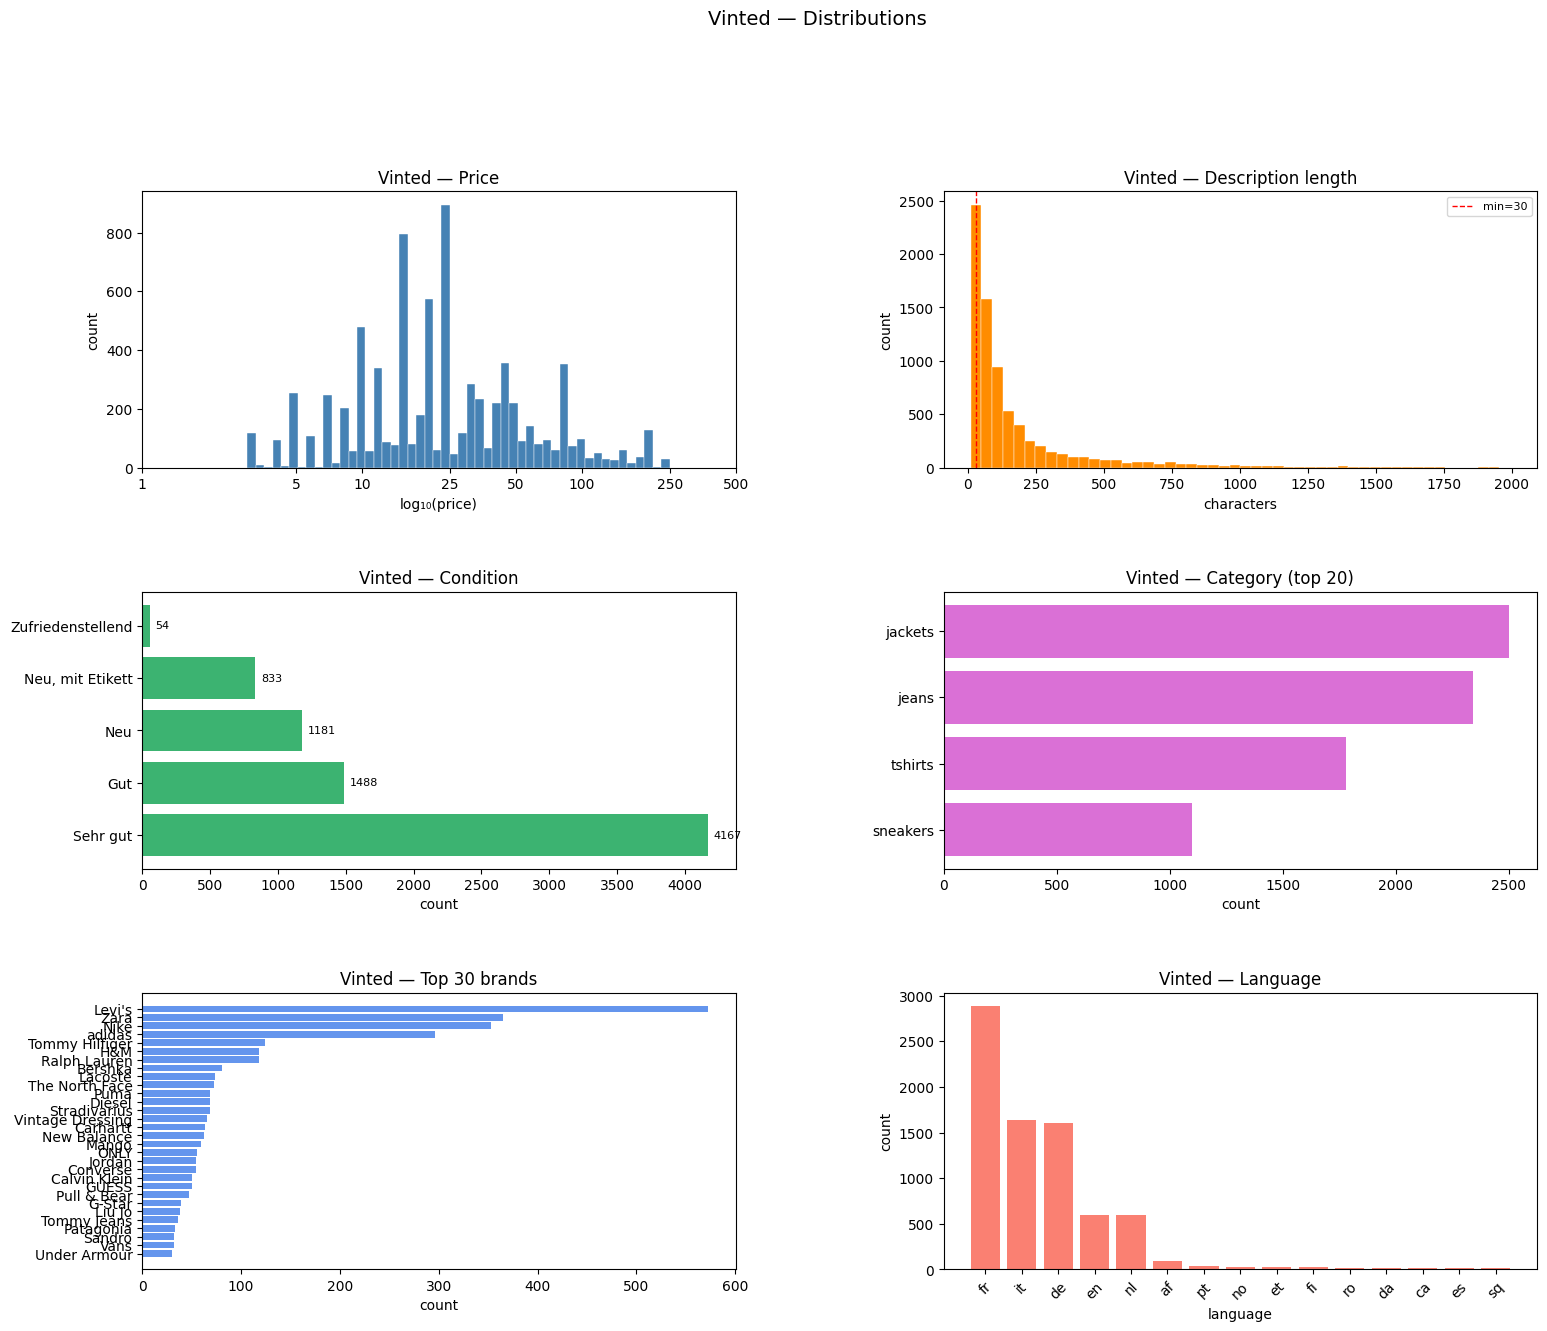

In [32]:
PRICE_COL_VT = find_col(vt, ['price', 'preis', 'Price'])
DESC_COL_VT  = find_col(vt, ['description', 'desc', 'body', 'text', TARGET_COL_VT] if TARGET_COL_VT else ['description', 'desc', 'body', 'text'])
COND_COL_VT  = find_col(vt, ['condition', 'zustand', 'Condition'])
BRAND_COL_VT = find_col(vt, ['brand', 'marke', 'Brand'])
CAT_COL_VT   = find_col(vt, ['category_name', 'category', 'kategorie', 'Category'])
LANG_COL_VT  = find_col(vt, ['language', 'lang', 'Language'])

cols_found = {k: v for k, v in {
    'price': PRICE_COL_VT, 'description': DESC_COL_VT, 'condition': COND_COL_VT,
    'brand': BRAND_COL_VT, 'category': CAT_COL_VT, 'language': LANG_COL_VT,
}.items() if v}
print('Mapped columns:', cols_found)

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Price (log scale)
ax = fig.add_subplot(gs[0, 0])
if PRICE_COL_VT:
    prices = pd.to_numeric(vt[PRICE_COL_VT], errors='coerce').dropna()
    prices = prices[prices > 0]
    ax.hist(np.log10(prices), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('log₁₀(price)')
    ax.set_ylabel('count')
    ax.set_title(f'Price distribution (log scale)  n={len(prices):,}')
    ticks = [1, 5, 10, 25, 50, 100, 250, 500]
    ax.set_xticks(np.log10(ticks))
    ax.set_xticklabels([str(t) for t in ticks])
else:
    ax.text(0.5, 0.5, 'price column not found', ha='center', va='center')
ax.set_title('Vinted — Price')

# Description length
ax = fig.add_subplot(gs[0, 1])
if DESC_COL_VT:
    lens = vt[DESC_COL_VT].dropna().str.len()
    ax.hist(lens, bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('characters')
    ax.set_ylabel('count')
    ax.axvline(30, color='red', linestyle='--', linewidth=1, label='min=30')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'description column not found', ha='center', va='center')
ax.set_title('Vinted — Description length')

# Condition
ax = fig.add_subplot(gs[1, 0])
if COND_COL_VT:
    vc = vt[COND_COL_VT].value_counts()
    ax.barh(vc.index.astype(str), vc.values, color='mediumseagreen')
    ax.set_xlabel('count')
    for j, v in enumerate(vc.values):
        ax.text(v + vc.values.max()*0.01, j, str(v), va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, 'condition column not found', ha='center', va='center')
ax.set_title('Vinted — Condition')

# Category
ax = fig.add_subplot(gs[1, 1])
if CAT_COL_VT:
    vc = vt[CAT_COL_VT].value_counts().head(20)
    ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color='orchid')
    ax.set_xlabel('count')
else:
    ax.text(0.5, 0.5, 'category column not found', ha='center', va='center')
ax.set_title('Vinted — Category (top 20)')

# Top 30 brands
ax = fig.add_subplot(gs[2, 0])
if BRAND_COL_VT:
    vc = vt[BRAND_COL_VT].value_counts().head(30)
    ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color='cornflowerblue')
    ax.set_xlabel('count')
else:
    ax.text(0.5, 0.5, 'brand column not found', ha='center', va='center')
ax.set_title('Vinted — Top 30 brands')

# Language
ax = fig.add_subplot(gs[2, 1])
if LANG_COL_VT:
    vc = vt[LANG_COL_VT].value_counts().head(15)
    ax.bar(vc.index.astype(str), vc.values, color='salmon')
    ax.set_xlabel('language')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    ax.set_title('Vinted — Language')
else:
    # Try langdetect on a sample
    try:
        from langdetect import detect
        sample_texts = vt[DESC_COL_VT].dropna().sample(min(200, len(vt)), random_state=SEED) if DESC_COL_VT else pd.Series([])
        langs = sample_texts.apply(lambda x: detect(x[:200]) if len(x) > 10 else 'unknown')
        vc = langs.value_counts()
        ax.bar(vc.index, vc.values, color='salmon')
        ax.set_xlabel('detected language (sample n=200)')
        ax.set_ylabel('count')
        ax.tick_params(axis='x', rotation=45)
        ax.set_title('Vinted — Language (detected)')
    except ImportError:
        ax.text(0.5, 0.5, 'no language column\n(pip install langdetect to detect)', ha='center', va='center', fontsize=9)
        ax.set_title('Vinted — Language')

plt.suptitle('Vinted — Distributions', fontsize=14, y=1.01)
plt.show()

In [33]:
# Image sanity check — try loading 50 random images
if IMG_COL_VT:
    sample_check = vt[IMG_COL_VT].sample(min(50, len(vt)), random_state=SEED)
    ok, failed, failed_idx = 0, 0, []
    for idx, val in sample_check.items():
        img = load_img(val)
        if img is None:
            failed += 1
            failed_idx.append(idx)
        else:
            ok += 1
    print(f"Vinted image sanity check (n=50):")
    print(f"  OK     : {ok}")
    print(f"  Failed : {failed}")
    if failed_idx:
        print(f"  Failed indices: {failed_idx}")
else:
    print('No image column — skipping sanity check.')

Vinted image sanity check (n=50):
  OK     : 50
  Failed : 0


---
## Kleinanzeigen

Image column : image
Text columns : ['target_text', 'title', 'description', 'category_name', 'price_type', 'currency', 'brand', 'size', 'color', 'condition', 'language', 'source_domain']


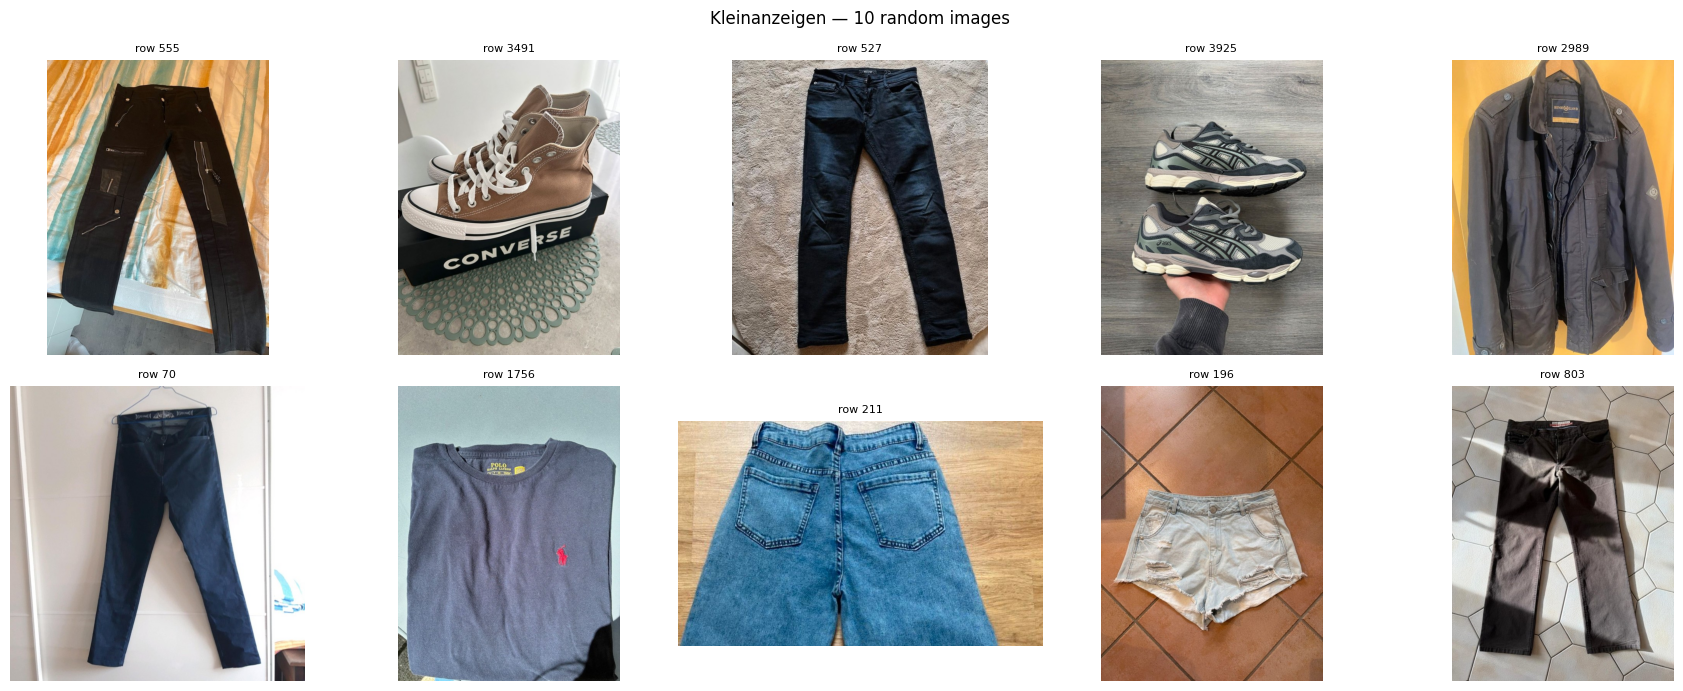


Text fields for the same 10 rows:


,target_text,title,description,category_name,price_type,currency,brand,size,color,condition,language,source_domain
0,Titel: Extravagante Jeans von Alexander McQueen\nBeschreibung: Stylische Hose - fällt auf!\nSieht aus wie neu - ist aber relativ schmal geschnitte...,Extravagante Jeans von Alexander McQueen,Stylische Hose - fällt auf!\nSieht aus wie neu - ist aber relativ schmal geschnitten.\nFür weitere Fotos und Infos einfach nachfragen :-),Herrenbekleidung,SPECIFIED_AMOUNT,EUR,Alexander McQueen,M,Schwarz,Sehr Gut,de,www.kleinanzeigen.de
1,"Titel: Converse Chuck All Star unisex neu Größe 39,5\nBeschreibung: Neues Converse\nVersand möglich\nKein Umtausch\nPrivatverkauf\nPaypal Freunde\...","Converse Chuck All Star unisex neu Größe 39,5",Neues Converse\nVersand möglich\nKein Umtausch\nPrivatverkauf\nPaypal Freunde,Damenschuhe,PLEASE_CONTACT,EUR,Converse,39.5,Braun,Neu,de,www.kleinanzeigen.de
2,Titel: Replay Herrenjeans Größe 29&#x2F;30 Top Zustand\nBeschreibung: Ich biete eine Replay Herrenjeans in der Größe 29/30 an. Diese Jeans ist in ...,Replay Herrenjeans Größe 29&#x2F;30 Top Zustand,"Ich biete eine Replay Herrenjeans in der Größe 29/30 an. Diese Jeans ist in einem top Zustand und wurde kaum getragen, was sie zu einer tollen Erg...",Herrenbekleidung,PLEASE_CONTACT,EUR,Replay,M,Schwarz,Sehr Gut,de,www.kleinanzeigen.de
3,Titel: Asics Gel NYC\nBeschreibung: Verkaufe den Asics Gel NYC in größe 42.\nSchuh ist mir etwas zu klein\nKategorie: Herrenschuhe\nPreis: 100.00 EUR,Asics Gel NYC,Verkaufe den Asics Gel NYC in größe 42.\nSchuh ist mir etwas zu klein,Herrenschuhe,PLEASE_CONTACT,EUR,ASICS,42,Beige,Neu,de,www.kleinanzeigen.de
4,"Titel: Jacke, Segeljacke, gefüttert, wasserdicht, Henry Lloyd\nBeschreibung: Jacke von Henry Lloyd.\nSegeljacke, leicht, gefüttert, wasserdicht.\n...","Jacke, Segeljacke, gefüttert, wasserdicht, Henry Lloyd","Jacke von Henry Lloyd.\nSegeljacke, leicht, gefüttert, wasserdicht.",Herrenbekleidung,PLEASE_CONTACT,EUR,Sonstige,XXXL,Blau,Gut,de,www.kleinanzeigen.de
5,"Titel: Jeans von Mustang\nBeschreibung: Hallo, hier biete ich eine dunkelblaue Mustang Jeans an. Sie ist ein vielseitiges Kleidungsstück, das sich...",Jeans von Mustang,"Hallo, hier biete ich eine dunkelblaue Mustang Jeans an. Sie ist ein vielseitiges Kleidungsstück, das sich gut kombinieren lässt und einen klassis...",Damenbekleidung,PLEASE_CONTACT,EUR,Mustang,L (40),Blau,Sehr Gut,de,www.kleinanzeigen.de
6,"Titel: 2-Pack Ralph Lauren T- Shirts , ORIGINAL , kein Fake\nBeschreibung: Doppelpack klassische T-Shirts, Original, kein\nFake ( Salzburg Airport...","2-Pack Ralph Lauren T- Shirts , ORIGINAL , kein Fake","Doppelpack klassische T-Shirts, Original, kein\nFake ( Salzburg Airport Center)",Herrenbekleidung,SPECIFIED_AMOUNT,EUR,Ralph Lauren,S,Blau,Sehr Gut,de,www.kleinanzeigen.de
7,"Titel: Neue moderne Jeans Gr M Baumwolle&#x2F;Elastan\nBeschreibung: Ich biete eine neue, ungetragene moderne Jeans in Größe M an. Diese Jeans ist...",Neue moderne Jeans Gr M Baumwolle&#x2F;Elastan,"Ich biete eine neue, ungetragene moderne Jeans in Größe M an. Diese Jeans ist aus einer bequemen Baumwoll-Elastan-Mischung gefertigt, die für eine...",Damenbekleidung,PLEASE_CONTACT,EUR,Sonstige,M (38),Blau,Neu,de,www.kleinanzeigen.de
8,Titel: Denim 1982 Jeansshorts Gr. 40 - Destroyed Look\nBeschreibung: Ich biete hier eine stylische Jeansshorts der Marke Denim 1982 in Größe 40 an...,Denim 1982 Jeansshorts Gr. 40 - Destroyed Look,Ich biete hier eine stylische Jeansshorts der Marke Denim 1982 in Größe 40 an. Diese Shorts sind perfekt für den Sommer und lassen sich vielseitig...,Damenbekleidung,SPECIFIED_AMOUNT,EUR,Sonstige,L (40),Blau,Sehr Gut,de,www.kleinanzeigen.de
9,Titel: Jeans Herren Brax\nBeschreibung: Verkaufe diese Jeanshose in der Größe W 38 L 30!\nKategorie: Herrenbekleidung\nPreis: 10.00 EUR,Jeans Herren Brax,Verkaufe diese Jeanshose in der Größe W 38 L 30!,Herrenbekleidung,SPECIFIED_AMOUNT,EUR,Brax,XL,Braun,Sehr Gut,de,www.kleinanzeigen.de


In [34]:
IMG_COL_KA = find_col(ka, ['image', 'image_bytes', 'photo', 'img'])
TXT_COLS_KA = [c for c in ka.columns if c != IMG_COL_KA and (pd.api.types.is_string_dtype(ka[c]) or ka[c].dtype == object)]

print(f"Image column : {IMG_COL_KA}")
print(f"Text columns : {TXT_COLS_KA}")

sample_ka = ka.sample(10, random_state=SEED)

if IMG_COL_KA:
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample_ka.iterrows()):
        img = load_img(row[IMG_COL_KA])
        if img:
            axes[i].imshow(img)
        else:
            axes[i].text(0.5, 0.5, 'no image', ha='center', va='center', fontsize=9)
        axes[i].set_title(f"row {row.name}", fontsize=8)
        axes[i].axis('off')
    plt.suptitle('Kleinanzeigen — 10 random images', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No image column found — skipping image grid')

print('\nText fields for the same 10 rows:')
display(sample_ka[TXT_COLS_KA].reset_index(drop=True))

In [35]:
TARGET_COL_KA = find_col(ka, ['target_text', 'description', 'text', 'listing_text', 'body'])
print(f"Target text column: {TARGET_COL_KA}\n")

if TARGET_COL_KA:
    for i, txt in enumerate(ka[TARGET_COL_KA].dropna().sample(10, random_state=SEED), 1):
        print(f"[{i}] {txt}\n{'─'*80}")
else:
    print('No target text column found.')

Target text column: target_text

[1] Titel: Extravagante Jeans von Alexander McQueen
Beschreibung: Stylische Hose - fällt auf!
Sieht aus wie neu - ist aber relativ schmal geschnitten.
Für weitere Fotos und Infos einfach nachfragen :-)
Kategorie: Herrenbekleidung
Preis: 135.00 EUR
────────────────────────────────────────────────────────────────────────────────
[2] Titel: Converse Chuck All Star unisex neu Größe 39,5
Beschreibung: Neues Converse
Versand möglich
Kein Umtausch
Privatverkauf
Paypal Freunde
Kategorie: Damenschuhe
Preis: 45.00 EUR
────────────────────────────────────────────────────────────────────────────────
[3] Titel: Replay Herrenjeans Größe 29&#x2F;30 Top Zustand
Beschreibung: Ich biete eine Replay Herrenjeans in der Größe 29/30 an. Diese Jeans ist in einem top Zustand und wurde kaum getragen, was sie zu einer tollen Ergänzung für deine Garderobe macht.

- Schwarze Waschung mit leichtem Used-Look
- Klassischer 5-Pocket-Stil
- Replay-Markenlabel auf der Rückseite
- Gerade

Mapped columns: {'price': 'price', 'description': 'description', 'condition': 'condition', 'brand': 'brand', 'category': 'category_name', 'language': 'language'}


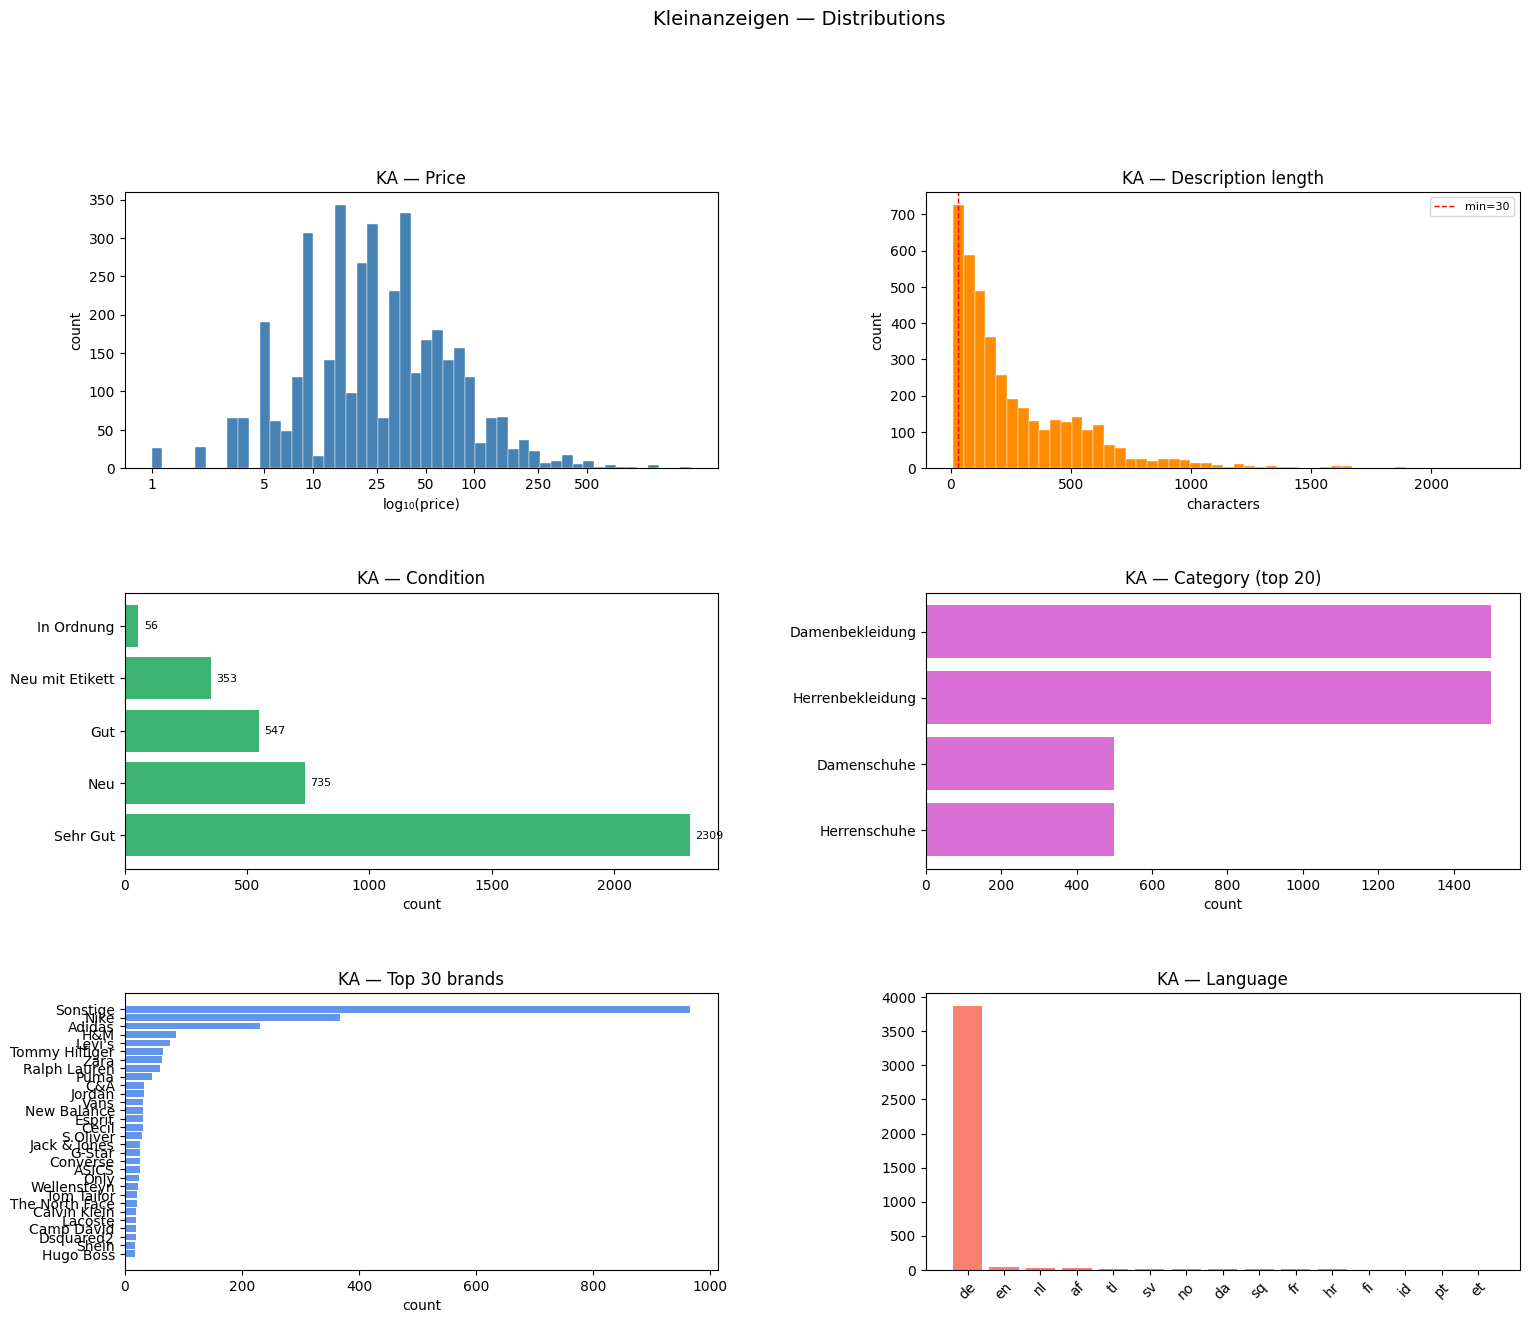

In [36]:
PRICE_COL_KA = find_col(ka, ['price', 'preis', 'Price'])
DESC_COL_KA  = find_col(ka, ['description', 'desc', 'body', 'text', TARGET_COL_KA] if TARGET_COL_KA else ['description', 'desc', 'body', 'text'])
COND_COL_KA  = find_col(ka, ['condition', 'zustand', 'Condition'])
BRAND_COL_KA = find_col(ka, ['brand', 'marke', 'Brand'])
CAT_COL_KA   = find_col(ka, ['category_name', 'category', 'kategorie', 'Category'])
LANG_COL_KA  = find_col(ka, ['language', 'lang', 'Language'])

print('Mapped columns:', {k: v for k, v in {
    'price': PRICE_COL_KA, 'description': DESC_COL_KA, 'condition': COND_COL_KA,
    'brand': BRAND_COL_KA, 'category': CAT_COL_KA, 'language': LANG_COL_KA,
}.items() if v})

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
if PRICE_COL_KA:
    prices = pd.to_numeric(ka[PRICE_COL_KA], errors='coerce').dropna()
    prices = prices[prices > 0]
    ax.hist(np.log10(prices), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ticks = [1, 5, 10, 25, 50, 100, 250, 500]
    ax.set_xticks(np.log10(ticks))
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_xlabel('log₁₀(price)')
    ax.set_ylabel('count')
else:
    ax.text(0.5, 0.5, 'price column not found', ha='center', va='center')
ax.set_title('KA — Price')

ax = fig.add_subplot(gs[0, 1])
if DESC_COL_KA:
    lens = ka[DESC_COL_KA].dropna().str.len()
    ax.hist(lens, bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
    ax.axvline(30, color='red', linestyle='--', linewidth=1, label='min=30')
    ax.legend(fontsize=8)
    ax.set_xlabel('characters')
    ax.set_ylabel('count')
else:
    ax.text(0.5, 0.5, 'description column not found', ha='center', va='center')
ax.set_title('KA — Description length')

ax = fig.add_subplot(gs[1, 0])
if COND_COL_KA:
    vc = ka[COND_COL_KA].value_counts()
    ax.barh(vc.index.astype(str), vc.values, color='mediumseagreen')
    ax.set_xlabel('count')
    for j, v in enumerate(vc.values):
        ax.text(v + vc.values.max()*0.01, j, str(v), va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, 'condition column not found', ha='center', va='center')
ax.set_title('KA — Condition')

ax = fig.add_subplot(gs[1, 1])
if CAT_COL_KA:
    vc = ka[CAT_COL_KA].value_counts().head(20)
    ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color='orchid')
    ax.set_xlabel('count')
else:
    ax.text(0.5, 0.5, 'category column not found', ha='center', va='center')
ax.set_title('KA — Category (top 20)')

ax = fig.add_subplot(gs[2, 0])
if BRAND_COL_KA:
    vc = ka[BRAND_COL_KA].value_counts().head(30)
    ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color='cornflowerblue')
    ax.set_xlabel('count')
else:
    ax.text(0.5, 0.5, 'brand column not found', ha='center', va='center')
ax.set_title('KA — Top 30 brands')

ax = fig.add_subplot(gs[2, 1])
if LANG_COL_KA:
    vc = ka[LANG_COL_KA].value_counts().head(15)
    ax.bar(vc.index.astype(str), vc.values, color='salmon')
    ax.tick_params(axis='x', rotation=45)
    ax.set_title('KA — Language')
else:
    try:
        from langdetect import detect
        sample_texts = ka[DESC_COL_KA].dropna().sample(min(200, len(ka)), random_state=SEED) if DESC_COL_KA else pd.Series([])
        langs = sample_texts.apply(lambda x: detect(x[:200]) if len(x) > 10 else 'unknown')
        vc = langs.value_counts()
        ax.bar(vc.index, vc.values, color='salmon')
        ax.tick_params(axis='x', rotation=45)
        ax.set_title('KA — Language (detected)')
    except ImportError:
        ax.text(0.5, 0.5, 'no language column\n(pip install langdetect to detect)', ha='center', va='center', fontsize=9)
        ax.set_title('KA — Language')

plt.suptitle('Kleinanzeigen — Distributions', fontsize=14, y=1.01)
plt.show()

In [37]:
if IMG_COL_KA:
    sample_check = ka[IMG_COL_KA].sample(min(50, len(ka)), random_state=SEED)
    ok, failed, failed_idx = 0, 0, []
    for idx, val in sample_check.items():
        img = load_img(val)
        if img is None:
            failed += 1
            failed_idx.append(idx)
        else:
            ok += 1
    print(f"Kleinanzeigen image sanity check (n=50):")
    print(f"  OK     : {ok}")
    print(f"  Failed : {failed}")
    if failed_idx:
        print(f"  Failed indices: {failed_idx}")
else:
    print('No image column — skipping sanity check.')

Kleinanzeigen image sanity check (n=50):
  OK     : 50
  Failed : 0


In [38]:
# price_type filter — KA rows with placeholder prices
print('KA price_type distribution:')
display(ka['price_type'].value_counts().rename('count').to_frame())

please_contact = (ka['price_type'] == 'PLEASE_CONTACT').sum()
pct = please_contact / len(ka) * 100
print(f"\nRows where price_type == 'PLEASE_CONTACT': {please_contact:,} ({pct:.1f}%)")
print('These rows have placeholder prices and must be excluded from price-head training.')

effective_ka = len(ka) - please_contact
print(f"\nEffective KA size after filtering: {effective_ka:,} rows ({effective_ka / len(ka) * 100:.1f}% retained)")


KA price_type distribution:


,count
price_type,
SPECIFIED_AMOUNT,2578
PLEASE_CONTACT,1404
FREE,18



Rows where price_type == 'PLEASE_CONTACT': 1,404 (35.1%)
These rows have placeholder prices and must be excluded from price-head training.

Effective KA size after filtering: 2,596 rows (64.9% retained)


---
## Cross-platform comparison

In [39]:
# Category taxonomy — raw unique values side by side
print('Vinted category_name values:')
if 'category_name' in vt.columns:
    display(vt['category_name'].value_counts().rename('count').to_frame())
else:
    print('  column not found')

print('\nKleinanzeigen category_name values:')
if 'category_name' in ka.columns:
    display(ka['category_name'].value_counts().rename('count').to_frame())
else:
    print('  column not found')

# Side-by-side as a merged DataFrame for quick diff
if 'category_name' in vt.columns and 'category_name' in ka.columns:
    vt_vc = vt['category_name'].value_counts().rename('vinted')
    ka_vc = ka['category_name'].value_counts().rename('kleinanzeigen')
    merged = pd.concat([vt_vc, ka_vc], axis=1).fillna(0).astype(int)
    merged.index.name = 'category_name'
    print('\nMerged (0 = not present on that platform):')
    display(merged.sort_index())


Vinted category_name values:


,count
category_name,
jackets,2502
jeans,2342
tshirts,1779
sneakers,1100



Kleinanzeigen category_name values:


,count
category_name,
Damenbekleidung,1500
Herrenbekleidung,1500
Damenschuhe,500
Herrenschuhe,500



Merged (0 = not present on that platform):


,vinted,kleinanzeigen
category_name,,
Damenbekleidung,0,1500
Damenschuhe,0,500
Herrenbekleidung,0,1500
Herrenschuhe,0,500
jackets,2502,0
jeans,2342,0
sneakers,1100,0
tshirts,1779,0


In [40]:
# Condition normalization sanity check
def normalize_condition(s):
    return s.str.lower().str.replace(',', '', regex=False).str.strip()

if COND_COL_VT:
    print('Vinted — raw condition values:')
    display(vt[COND_COL_VT].value_counts().rename('count').to_frame())

if COND_COL_KA:
    print('\nKleinanzeigen — raw condition values:')
    display(ka[COND_COL_KA].value_counts().rename('count').to_frame())

if COND_COL_VT and COND_COL_KA:
    vt_norm = normalize_condition(vt[COND_COL_VT])
    ka_norm = normalize_condition(ka[COND_COL_KA])
    combined = pd.concat([vt_norm, ka_norm], ignore_index=True)
    print('\nNormalized condition values (both platforms combined):')
    display(combined.value_counts().rename('count').to_frame())


Vinted — raw condition values:


,count
condition,
Sehr gut,4167
Gut,1488
Neu,1181
"Neu, mit Etikett",833
Zufriedenstellend,54



Kleinanzeigen — raw condition values:


,count
condition,
Sehr Gut,2309
Neu,735
Gut,547
Neu mit Etikett,353
In Ordnung,56



Normalized condition values (both platforms combined):


,count
condition,
sehr gut,6476
gut,2035
neu,1916
neu mit etikett,1186
in ordnung,56
zufriedenstellend,54


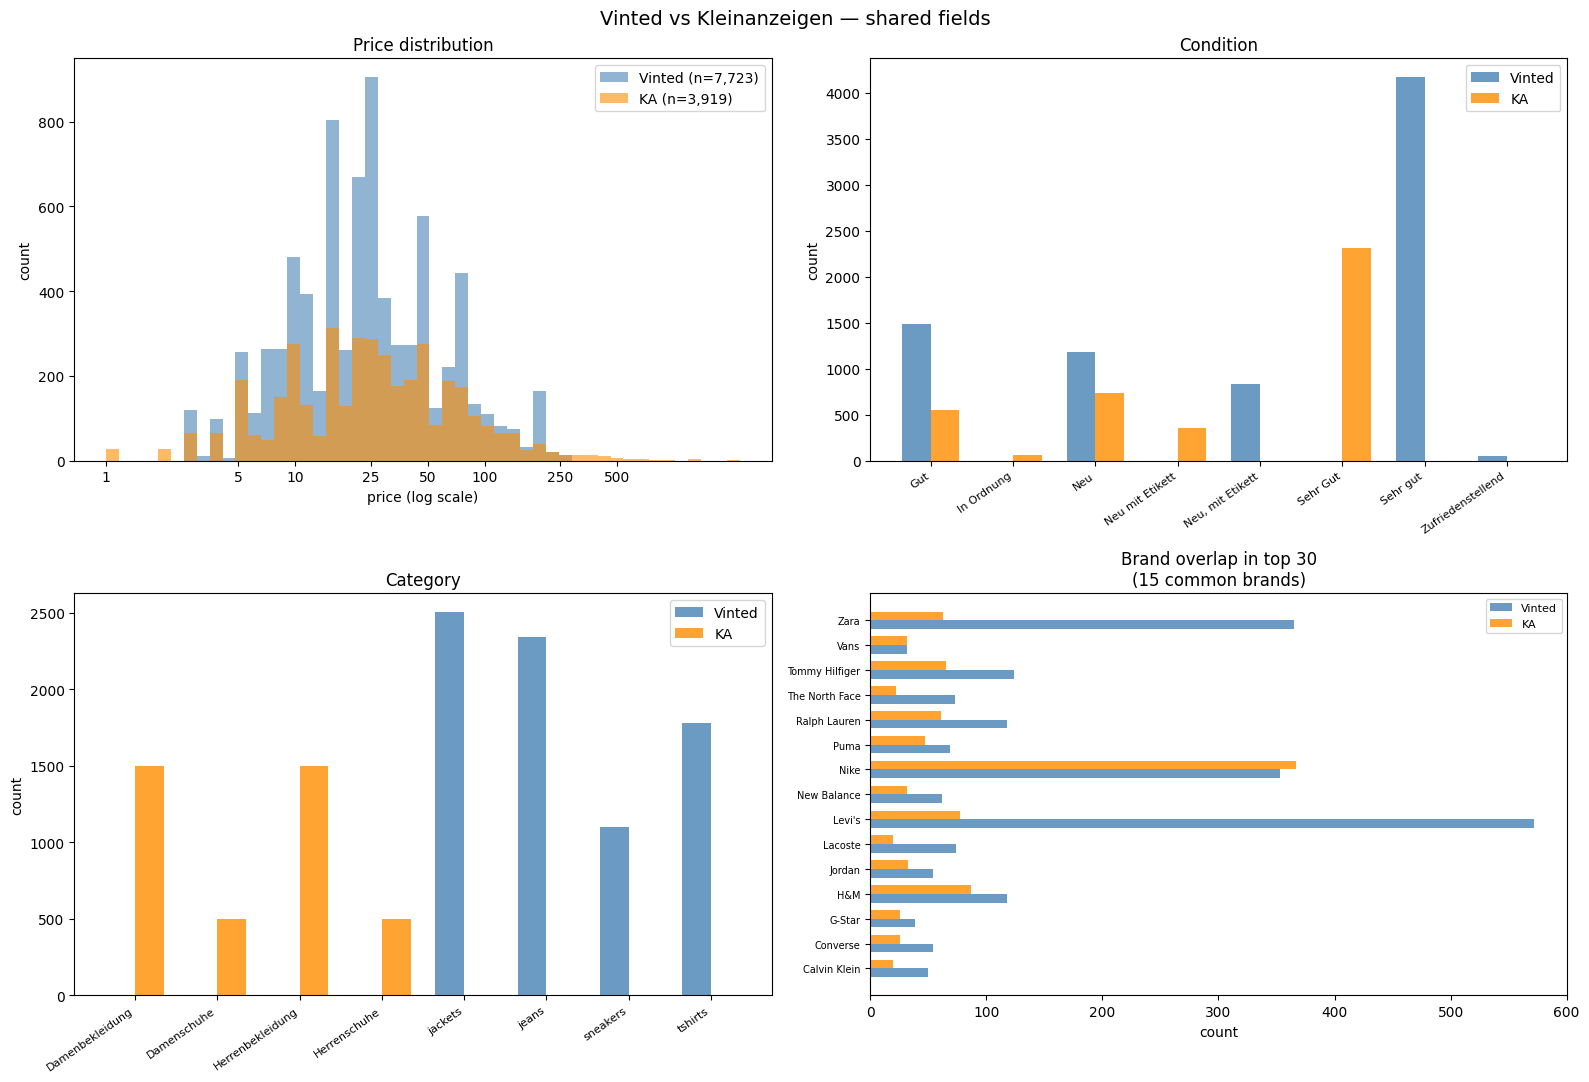


Price summary:
  Vinted          median=22.90  mean=35.55  p10=7.00  p90=80.00
  KA              median=25.00  mean=45.76  p10=6.00  p90=90.00


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Vinted vs Kleinanzeigen — shared fields', fontsize=14)

# Price
ax = axes[0, 0]
vt_price = pd.to_numeric(vt[PRICE_COL_VT], errors='coerce').dropna() if PRICE_COL_VT else pd.Series([], dtype=float)
ka_price = pd.to_numeric(ka[PRICE_COL_KA], errors='coerce').dropna() if PRICE_COL_KA else pd.Series([], dtype=float)
vt_price = vt_price[vt_price > 0]
ka_price = ka_price[ka_price > 0]
bins = np.linspace(
    min(np.log10(vt_price.min()) if len(vt_price) else 0, np.log10(ka_price.min()) if len(ka_price) else 0),
    max(np.log10(vt_price.max()) if len(vt_price) else 3, np.log10(ka_price.max()) if len(ka_price) else 3),
    50
)
if len(vt_price): ax.hist(np.log10(vt_price), bins=bins, alpha=0.6, label=f'Vinted (n={len(vt_price):,})', color='steelblue')
if len(ka_price): ax.hist(np.log10(ka_price), bins=bins, alpha=0.6, label=f'KA (n={len(ka_price):,})', color='darkorange')
ticks = [1, 5, 10, 25, 50, 100, 250, 500]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([str(t) for t in ticks])
ax.set_xlabel('price (log scale)')
ax.set_ylabel('count')
ax.legend()
ax.set_title('Price distribution')

# Condition
ax = axes[0, 1]
if COND_COL_VT and COND_COL_KA:
    all_conds = sorted(set(vt[COND_COL_VT].dropna().unique()) | set(ka[COND_COL_KA].dropna().unique()))
    vt_c = vt[COND_COL_VT].value_counts().reindex(all_conds, fill_value=0)
    ka_c = ka[COND_COL_KA].value_counts().reindex(all_conds, fill_value=0)
    x = np.arange(len(all_conds))
    w = 0.35
    ax.bar(x - w/2, vt_c.values, w, label='Vinted', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, ka_c.values, w, label='KA', color='darkorange', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in all_conds], rotation=35, ha='right', fontsize=8)
    ax.legend()
elif COND_COL_VT:
    vt[COND_COL_VT].value_counts().plot(kind='bar', ax=ax, color='steelblue', label='Vinted')
    ax.set_title('Vinted only (KA condition col not found)')
elif COND_COL_KA:
    ka[COND_COL_KA].value_counts().plot(kind='bar', ax=ax, color='darkorange', label='KA')
    ax.set_title('KA only (Vinted condition col not found)')
else:
    ax.text(0.5, 0.5, 'condition columns not found', ha='center', va='center')
ax.set_title('Condition')
ax.set_ylabel('count')

# Category
ax = axes[1, 0]
if CAT_COL_VT and CAT_COL_KA:
    all_cats = sorted(set(vt[CAT_COL_VT].dropna().unique()) | set(ka[CAT_COL_KA].dropna().unique()))
    vt_c = vt[CAT_COL_VT].value_counts().reindex(all_cats, fill_value=0)
    ka_c = ka[CAT_COL_KA].value_counts().reindex(all_cats, fill_value=0)
    x = np.arange(len(all_cats))
    w = 0.35
    ax.bar(x - w/2, vt_c.values, w, label='Vinted', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, ka_c.values, w, label='KA', color='darkorange', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in all_cats], rotation=35, ha='right', fontsize=8)
    ax.legend()
elif CAT_COL_VT:
    vt[CAT_COL_VT].value_counts().head(15).plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Vinted only (KA category col not found)')
    ax.tick_params(axis='x', rotation=35)
elif CAT_COL_KA:
    ka[CAT_COL_KA].value_counts().head(15).plot(kind='bar', ax=ax, color='darkorange')
    ax.set_title('KA only (Vinted category col not found)')
    ax.tick_params(axis='x', rotation=35)
else:
    ax.text(0.5, 0.5, 'category columns not found', ha='center', va='center')
ax.set_title('Category')
ax.set_ylabel('count')

# Top brands overlap
ax = axes[1, 1]
if BRAND_COL_VT and BRAND_COL_KA:
    top_vt = set(vt[BRAND_COL_VT].value_counts().head(30).index)
    top_ka = set(ka[BRAND_COL_KA].value_counts().head(30).index)
    overlap = sorted(top_vt & top_ka)
    vt_counts = vt[BRAND_COL_VT].value_counts().reindex(overlap, fill_value=0)
    ka_counts = ka[BRAND_COL_KA].value_counts().reindex(overlap, fill_value=0)
    if overlap:
        x = np.arange(len(overlap))
        w = 0.35
        ax.barh(x - w/2, vt_counts.values, w, label='Vinted', color='steelblue', alpha=0.8)
        ax.barh(x + w/2, ka_counts.values, w, label='KA', color='darkorange', alpha=0.8)
        ax.set_yticks(x)
        ax.set_yticklabels(overlap, fontsize=7)
        ax.legend(fontsize=8)
        ax.set_xlabel('count')
    else:
        ax.text(0.5, 0.5, 'No brand overlap in top 30', ha='center', va='center')
    ax.set_title(f'Brand overlap in top 30\n({len(overlap)} common brands)')
else:
    ax.text(0.5, 0.5, 'brand columns not found\non one or both platforms', ha='center', va='center')
    ax.set_title('Top brands overlap')

plt.tight_layout()
plt.show()

# Summary stats for price
print('\nPrice summary:')
for name, col, df in [('Vinted', PRICE_COL_VT, vt), ('KA', PRICE_COL_KA, ka)]:
    if col:
        p = pd.to_numeric(df[col], errors='coerce').dropna()
        p = p[p > 0]
        print(f"  {name:<15} median={p.median():.2f}  mean={p.mean():.2f}  p10={p.quantile(0.1):.2f}  p90={p.quantile(0.9):.2f}")
    else:
        print(f"  {name:<15} price column not found")

In [42]:
# Class balance overview — flaw head, categories, brands

def _norm(s):
    return s.str.lower().str.replace(',', '', regex=False).str.strip()

print('=' * 60)
print('FLAW HEAD — class balance')
print('=' * 60)
all_cond = pd.concat([_norm(vt['condition']), _norm(ka['condition'])], ignore_index=True)
keep = all_cond[~all_cond.isin({'in ordnung', 'zufriedenstellend'})]
pos = (keep == 'gut').sum()
neg = keep.isin({'sehr gut', 'neu', 'neu mit etikett'}).sum()
print(f'  Positive (gut)                          : {pos:,}')
print(f'  Negative (sehr gut / neu / neu mit etikett): {neg:,}')
print(f'  Ratio pos:neg                           : 1:{neg/pos:.1f}')
print(f'  Implied pos_weight                      : {neg/pos:.2f}')

print('\n' + '=' * 60)
print('CATEGORIES — value counts per platform')
print('=' * 60)
print('\nVinted:')
display(vt['category_name'].value_counts().rename('count').to_frame())
print('\nKleinanzeigen:')
display(ka['category_name'].value_counts().rename('count').to_frame())

print('\n' + '=' * 60)
print('BRANDS — top 30 per platform + long-tail size')
print('=' * 60)
for name, df in [('Vinted', vt), ('KA', ka)]:
    vc = df['brand'].value_counts()
    top30 = vc.head(30)
    tail = vc.iloc[30:].sum() if len(vc) > 30 else 0
    print(f'\n{name} — top 30 brands:')
    display(top30.rename('count').to_frame())
    print(f'  Long-tail rows (rank > 30): {tail:,} ({tail / len(df) * 100:.1f}% of dataset)')
    if name == 'KA':
        sonstige = vc.get('Sonstige', 0)
        print(f"  ⚠  'Sonstige' bucket: {sonstige:,} rows ({sonstige / len(df) * 100:.1f}%) — map to UNK")


FLAW HEAD — class balance
  Positive (gut)                          : 2,035
  Negative (sehr gut / neu / neu mit etikett): 9,578
  Ratio pos:neg                           : 1:4.7
  Implied pos_weight                      : 4.71

CATEGORIES — value counts per platform

Vinted:


,count
category_name,
jackets,2502
jeans,2342
tshirts,1779
sneakers,1100



Kleinanzeigen:


,count
category_name,
Damenbekleidung,1500
Herrenbekleidung,1500
Damenschuhe,500
Herrenschuhe,500



BRANDS — top 30 per platform + long-tail size

Vinted — top 30 brands:


,count
brand,
Levi's,572
Zara,365
Nike,353
adidas,296
Tommy Hilfiger,124
H&M,118
Ralph Lauren,118
Bershka,81
Lacoste,74


  Long-tail rows (rank > 30): 4,409 (57.1% of dataset)

KA — top 30 brands:


,count
brand,
Sonstige,965
Nike,367
Adidas,231
H&M,87
Levi's,77
Tommy Hilfiger,65
Zara,63
Ralph Lauren,61
Puma,47


  Long-tail rows (rank > 30): 1,505 (37.6% of dataset)
  ⚠  'Sonstige' bucket: 965 rows (24.1%) — map to UNK
